# Decoration Extractor — Medieval Manuscript Pages

Extract and categorise visual decorations (decorated initials, filigrees, marginalia, large decorations) from manuscript pages processed by the pipeline.

## Workflow

```
pkl results  →  visualise raw page
             →  [optional] remove text-line regions
             →  [optional] apply figure mask
             →  pretrained model detection
             →  map labels → categories
             →  count & visualise
```

## Notes on pretrained models

Three practical options, roughly in order of effort:

| Backend | Model | Pros | Cons |
|---|---|---|---|
| **Florence-2** (`microsoft/Florence-2-base`) | Open-vocabulary detection via text prompts — *zero-shot, no training* | Best for rapid iteration; runs on CPU/MPS; already available via `transformers` | Slower than YOLO; category quality depends on prompt wording |
| **YOLOv8 / YOLO11** | Generic COCO pretrained | Fast; easy to fine-tune | COCO labels are not manuscript-specific; needs fine-tuning for good results |
| **LayoutParser + PubLayNet / HJDataset** | Detectron2 pretrained on historical document layouts | Has "figure" label relevant to decorations | Best suited for printed layouts; medieval pages differ significantly |

**Recommended starting point:** Florence-2 with explicit text prompts for your four categories.  Once you have annotated examples, switch to YOLOv8 fine-tuned on those annotations.

**Important assumption:** The model runs on the **full cropped page** (`pre.bgr`), not only `figure_binary` regions, because marginalia may lie entirely outside Kraken text-line polygons and thus outside `figure_binary`.

## 1 — Imports & Configuration

In [22]:
from __future__ import annotations

import pickle
import sys
from pathlib import Path
from collections import Counter
from typing import List, Optional

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Project root on path ──────────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  — edit these before running
# ─────────────────────────────────────────────────────────────────────────────

image_name = "MS-GG-00001-00001-000-00021_double_more_complex_filigranes.jpg"
image_name = "MS-GG-00001-00001-000-00726_double_many_figures.jpg"
image_name = "MS-GG-00001-00001-000-00175_double_packed_center.jpg"
# Path to the source image that was processed by the pipeline
IMAGE_PATH = Path("../data/exemplars/" + image_name)

# The matching pickle is inferred automatically as  <image_dir>/results/<stem>.pkl
# Override here if yours is somewhere else:
RESULTS_PKL_PATH: Optional[Path] = None   # None → auto-detect

# ── Pre-processing toggles ────────────────────────────────────────────────────
REMOVE_LINES    = False   # paint out Kraken text-line regions before detection
USE_FIGURE_MASK = False  # restrict detection to figure_binary regions only
                        # (disables marginalia detection — see notebook intro)

# ── Model backend ─────────────────────────────────────────────────────────────
# 'florence2' — zero-shot, text-prompted (recommended for first iteration)
# 'yolo'      — YOLOv8 generic COCO pretrained (fast; needs fine-tuning later)
MODEL_BACKEND = "medieval_yolo" #"medieval_yolo", "florence2", "florence2_medieval"
MEDIEVAL_YOLO_SIZE = "x"  # "n" (nano), "s" (small), "m" (medium), "l" (large), "x" (extra-large)


CONFIDENCE_THRESHOLD = 0.20   # detections below this score are dropped

# ── Florence-2 prompts (only used when MODEL_BACKEND == 'florence2') ──────────
# Comma-separated labels sent to the open-vocabulary detector.
# Tune these — precision vs. recall trade-off is controlled here.
FLORENCE2_PROMPTS = (
    "decorated initial . filigree initial . illuminated letter . "
    "marginalia . large miniature . decorated border"
)

# ── Category mapping (applied after model inference) ─────────────────────────
# Map raw model label → one of the four target categories.
# Florence-2 returns the prompt text as the label; YOLO returns COCO class names.
CATEGORY_MAP = {
    # Florence-2 labels (from FLORENCE2_PROMPTS above)
    "decorated initial":   "decorated_initial",
    "filigree initial":    "initial_filigree",
    "illuminated letter":  "decorated_initial",
    "marginalia":          "marginalia",
    "large miniature":     "large_decoration",
    "decorated border":    "large_decoration",
    # Generic YOLO / LayoutParser labels
    "figure":              "large_decoration",
    "picture":             "large_decoration",
    "illustration":        "large_decoration",
    # Medieval YOLO / LayoutParser labels
    "dropcapitalzone":     "decorated_initial",
    "mainzone":            "other_interesting",  # not a decoration, but keep for analysis
    "graphiczone":         "large_decoration",
    "defaultline":         "other",
    "headingline":        "other_interesting",  # not a decoration, but keep for analysis
    "dropcapitalline":    "other_interesting",  # not a decoration, but keep for analysis
}

CATEGORY_COLORS = {
    "decorated_initial": (220,  50,  50),   # red   (BGR)
    "initial_filigree":  ( 50, 180,  50),   # green
    "marginalia":        ( 50,  50, 220),   # blue
    "large_decoration":  (200, 140,  30),   # orange
    "other":             (160, 160, 160),   # grey  (unmapped)
    "other_interesting":   ( 50, 200, 200),   # yellow (unmapped but "interesting" labels)
}

print("Configuration loaded.")

Configuration loaded.


## 2 — Load Pipeline Results

In [23]:
img_path = Path(IMAGE_PATH).expanduser().resolve()
assert img_path.is_file(), f"Image not found: {img_path}"

# Auto-detect pkl path: <image_dir>/results/<stem>.pkl
pkl_path = (
    RESULTS_PKL_PATH
    if RESULTS_PKL_PATH is not None
    else img_path.parent / "results" / img_path.with_suffix(".pkl").name
)
assert pkl_path.is_file(), (
    f"Pickle not found: {pkl_path}\n"
    "Run run_pipeline.py on the image first, or set RESULTS_PKL_PATH manually."
)

with open(pkl_path, "rb") as fh:
    result = pickle.load(fh)

pre  = result["pre"]    # PreprocessResult
seg  = result["seg"]    # SegmentKrakenResult
post = result["post"]   # PostprocessResult

print(f"Image  : {img_path.name}")
print(f"Size   : {pre.image_w} × {pre.image_h} px")
print(f"Binding: {pre.binding_side}  |  skew: {pre.deskew_angle:.2f}°")
print(f"Lines  : {seg.n_lines} raw  →  {post.n_lines} after filtering")
print(f"Figures: {seg.n_figures} raw  →  {post.n_figures} after filtering")
print(f"Figure coverage: {seg.figure_coverage:.2%}")

Image  : MS-GG-00001-00001-000-00175_double_packed_center.jpg
Size   : 935 × 1389 px
Binding: left  |  skew: -0.50°
Lines  : 85 raw  →  70 after filtering
Figures: 12 raw  →  0 after filtering
Figure coverage: 0.91%


## 3 — Visualise Raw Page & Masks

Red polygons = Kraken text lines (`post.line_boundaries`).  
Yellow tint = figure ink (`seg.figure_binary`).  
This replicates the `_save_result_image` logic for interactive inspection.

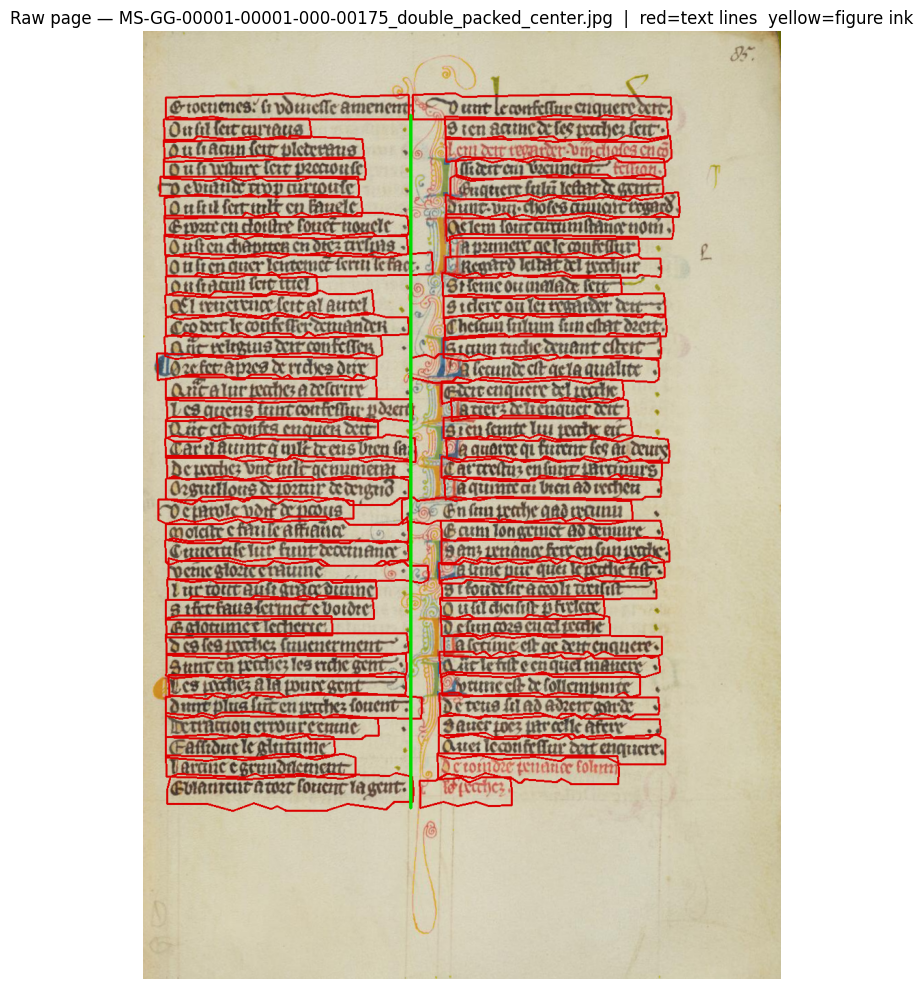

In [24]:
def show_bgr(bgr: np.ndarray, title: str = "", figsize=(14, 10)) -> None:
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


annotated = pre.bgr.copy()

# Yellow tint over figure ink
if seg.figure_binary is not None and seg.figure_binary.any():
    overlay = annotated.copy()
    overlay[seg.figure_binary > 0] = (0, 220, 220)   # BGR yellow
    cv2.addWeighted(overlay, 0.4, annotated, 0.6, 0, annotated)

# Red line-boundary polygons
for boundary in post.line_boundaries:
    pts = np.array(boundary, dtype=np.int32).reshape(-1, 1, 2)
    cv2.polylines(annotated, [pts], isClosed=True, color=(0, 0, 220), thickness=2)

# Green gutter line for double-column pages
if post.is_double_column and post.gutter_x is not None:
    cv2.line(annotated,
            (post.gutter_x, post.gutter_y_min),
            (post.gutter_x, post.gutter_y_max),
            (0, 220, 0), thickness=4)

show_bgr(annotated, title=f"Raw page — {img_path.name}  |  red=text lines  yellow=figure ink")

## 4 — Line Region Removal (Optional)

When `REMOVE_LINES = True`, every pixel inside a Kraken text-line polygon is painted to the mean background colour of the page.  This reduces noise for decoration detectors that are confused by dense handwriting.

In [27]:
def remove_text_lines(bgr: np.ndarray, line_boundaries: list) -> np.ndarray:
    """Paint all text-line polygon interiors to the page background colour."""
    out = bgr.copy()
    # Use the 95th-percentile brightness as a proxy for the parchment colour
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    bg_val = int(np.percentile(gray, 95))
    bg_color = (bg_val, bg_val, bg_val)   # neutral grey/white fill

    for boundary in line_boundaries:
        pts = np.array(boundary, dtype=np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(out, [pts], color=bg_color)
    return out


# Apply (or skip) based on toggle
if REMOVE_LINES:
    img_proc = remove_text_lines(pre.bgr, post.line_boundaries)
    show_bgr(img_proc, title="After text-line removal")
else:
    img_proc = pre.bgr.copy()
    print("REMOVE_LINES = False — passing original image unchanged.")

REMOVE_LINES = False — passing original image unchanged.


## 5 — Figure Mask Filtering (Optional)

When `USE_FIGURE_MASK = True`, only pixels inside `seg.figure_binary` are kept.  All other pixels are set to the background colour.

⚠️ **This will suppress marginalia** that fall outside any Kraken text-line polygon but also outside the current `figure_binary` region.  Keep `False` if marginalia detection is a priority.

In [28]:
if USE_FIGURE_MASK and seg.figure_binary is not None:
    gray = cv2.cvtColor(img_proc, cv2.COLOR_BGR2GRAY)
    bg_val = int(np.percentile(gray, 95))

    mask = seg.figure_binary > 0          # True = keep
    img_model_input = img_proc.copy()
    img_model_input[~mask] = bg_val       # blank out non-figure regions
    show_bgr(img_model_input, title="After figure mask filtering")
else:
    img_model_input = img_proc
    if USE_FIGURE_MASK:
        print("USE_FIGURE_MASK = True but figure_binary is empty — skipping.")
    else:
        print("USE_FIGURE_MASK = False — passing image unchanged.")

USE_FIGURE_MASK = False — passing image unchanged.


## 6 — Model Selection & Loading

Three backends are supported. Set `MODEL_BACKEND` in Section 1.

- **`florence2`** — `microsoft/Florence-2-base` loaded via `transformers`. Zero-shot, text-prompted. No GPU required; MPS accelerated on Apple Silicon.
- **`yolo`** — YOLOv8/11 via `ultralytics`. Generic COCO pretrained. Fast, but COCO labels have little manuscript relevance without fine-tuning.
- **`medieval_yolo`** ⭐ — `biglam/medieval-manuscript-yolov11` via `ultralytics`. YOLOv11 fine-tuned on [CATMuS/medieval-segmentation](https://huggingface.co/datasets/CATMuS/medieval-segmentation) using [SegmOnto](https://segmonto.github.io/) labels. **Recommended.** Set `MEDIEVAL_YOLO_SIZE` (`n`/`s`/`m`/`l`/`x`) to trade speed for accuracy. Downloads the checkpoint automatically on first run (5–114 MB depending on size). Relevant SegmOnto classes: `DropCapitalZone` → `decorated_initial`, `GraphicZone` → `large_decoration`, `MarginTextZone` → `marginalia`.

In [31]:
import torch

_device = (
    "mps"  if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {_device}")

if MODEL_BACKEND in ("florence2", "florence2_medieval"):
    from transformers import AutoProcessor, AutoModelForCausalLM

    if MODEL_BACKEND == "florence2_medieval":
        _FLORENCE_MODEL_ID = "medieval-data/florence2-medieval-bbox-zone-detection"
    elif MODEL_BACKEND == "florence2":
        _FLORENCE_MODEL_ID = "microsoft/Florence-2-base"

    
    print(f"Loading Florence-2 from {_FLORENCE_MODEL_ID} …")

    _florence_processor = AutoProcessor.from_pretrained(
        _FLORENCE_MODEL_ID, trust_remote_code=True
    )
    _florence_model = AutoModelForCausalLM.from_pretrained(
        _FLORENCE_MODEL_ID, trust_remote_code=True, attn_implementation="eager"
    ).to(_device).eval()

    if MODEL_BACKEND == "florence2_medieval":
        # The fine-tune's [modeling_florence2.py](http://_vscodecontentref_/3) forgot to include GenerationMixin
        # in Florence2LanguageForConditionalGeneration (the working microsoft/Florence-2-base
        # file has it; this one doesn't). In transformers 4.45+ GenerationMixin was
        # decoupled from PreTrainedModel, so generation_config is also not auto-set.
        from transformers.generation.utils import GenerationMixin as _GenMixin
        from transformers import GenerationConfig as _GenConfig
        _lang_cls = type(_florence_model.language_model)
        if not issubclass(_lang_cls, _GenMixin):
            _lang_cls.__bases__ = _lang_cls.__bases__ + (_GenMixin,)
        _florence_model.language_model.generation_config = _GenConfig.from_model_config(
            _florence_model.language_model.config
        )
        print("Applied GenerationMixin + generation_config patch to language model.")
        print("Florence-2 ready.")
        
elif MODEL_BACKEND in ("yolo", "medieval_yolo"):
    try:
        from ultralytics import YOLO as _YOLO
    except ImportError:
        raise ImportError(
            "ultralytics is not installed.\n"
            "Run:  pip install ultralytics\n"
            "Then restart the kernel."
        )

    if MODEL_BACKEND == "medieval_yolo":
        from huggingface_hub import hf_hub_download
        _filename = f"medieval-yolov11{MEDIEVAL_YOLO_SIZE}.pt"
        print(f"Downloading {_filename} from biglam/medieval-manuscript-yolov11 …")
        print("(Cached locally after first download)")
        _ckpt = hf_hub_download(
            repo_id="biglam/medieval-manuscript-yolov11",
            filename=_filename,
        )
        print(f"Checkpoint: {_ckpt}")
    else:
        _ckpt = "yolov8n.pt"
        print("Loading generic YOLOv8n (COCO) …")

    _yolo_model = _YOLO(_ckpt)
    print(f"YOLO ready.  Classes ({len(_yolo_model.names)}): {list(_yolo_model.names.values())}")

else:
    raise ValueError(
        f"Unknown MODEL_BACKEND: {MODEL_BACKEND!r}.  "
        "Use 'florence2', 'yolo', or 'medieval_yolo'."
    )

Using device: mps
(Cached locally after first download)
Checkpoint: /Users/luissalamanca/.cache/huggingface/hub/models--biglam--medieval-manuscript-yolov11/snapshots/8f5eddd64065fdd660317e3578028ee9b040c495/medieval-yolov11x.pt
YOLO ready.  Classes (18): ['MarginTextZone', 'DefaultLine', 'MainZone', 'RunningTitleZone', 'NumberingZone', 'QuireMarksZone', 'HeadingLine', 'DropCapitalZone', 'StampZone', 'GraphicZone', 'InterlinearLine', 'DigitizationArtefactZone', 'DropCapitalLine', 'DamageZone', 'MusicLine', 'TitlePageZone', 'SealZone', 'MusicZone']


## 7 — Run Detection

The preprocessed image (`img_model_input`) is passed to the selected model.  Raw detections are collected as a list of `(x1, y1, x2, y2, score, raw_label)` tuples.

In [32]:
from PIL import Image as _PILImage

# raw_detections: list of (x1, y1, x2, y2, score, raw_label)
raw_detections: List[tuple] = []

img_h, img_w = img_model_input.shape[:2]

# ── Florence-2 ────────────────────────────────────────────────────────────────
if MODEL_BACKEND == "florence2":
    img_pil = _PILImage.fromarray(cv2.cvtColor(img_model_input, cv2.COLOR_BGR2RGB))
    task = "<OPEN_VOCABULARY_DETECTION>"

    inputs = _florence_processor(
        text=task + FLORENCE2_PROMPTS,
        images=img_pil,
        return_tensors="pt",
    ).to(_device)

    with torch.no_grad():
        generated_ids = _florence_model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=False,
            use_cache=False,
        )

    generated_text = _florence_processor.batch_decode(
        generated_ids, skip_special_tokens=False
    )[0]

    parsed = _florence_processor.post_process_generation(
        generated_text,
        task=task,
        image_size=(img_w, img_h),
    )

    detections = parsed.get(task, {})
    bboxes = detections.get("bboxes", [])
    labels = detections.get("labels", [])

    for (x1, y1, x2, y2), label in zip(bboxes, labels):
        # Florence-2 does not provide per-box confidence in this task;
        # set score to 1.0 and filter by visual quality in later steps.
        raw_detections.append((
            int(x1), int(y1), int(x2), int(y2), 1.0, label.lower().strip()
        ))

elif MODEL_BACKEND == "florence2_medieval":
    
    print("Using Florence-2 medieval fine-tuned model — no prompts needed.")
    
    img_pil = _PILImage.fromarray(cv2.cvtColor(img_model_input, cv2.COLOR_BGR2RGB))
    task = "<OPEN_VOCABULARY_DETECTION>"

    task = "<OD>"
    
    inputs = _florence_processor(
        text=task,
        images=img_pil,
        return_tensors="pt",
    ).to(_device)

    with torch.no_grad():
        generated_ids = _florence_model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=False,
            use_cache=False,
        )

    generated_text = _florence_processor.batch_decode(
        generated_ids, skip_special_tokens=False
    )[0]

    parsed = _florence_processor.post_process_generation(
        generated_text,
        task=task,
        image_size=(img_w, img_h),
    )

    detections = parsed.get(task, {})
    bboxes = detections.get("bboxes", [])
    labels = detections.get("labels", [])

    for (x1, y1, x2, y2), label in zip(bboxes, labels):
        raw_detections.append((
            int(x1), int(y1), int(x2), int(y2), 1.0, label.lower().strip()
        ))

# ── YOLOv8/11 (generic COCO or medieval fine-tune) ───────────────────────────
elif MODEL_BACKEND in ("yolo", "medieval_yolo"):
    results = _yolo_model(img_model_input, conf=CONFIDENCE_THRESHOLD, verbose=False)
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            score = float(box.conf[0])
            cls_id = int(box.cls[0])
            # Normalise: lowercase, strip spaces for CATEGORY_MAP lookup
            label = _yolo_model.names[cls_id].lower().replace(" ", "")
            raw_detections.append((int(x1), int(y1), int(x2), int(y2), score, label))

print(f"Raw detections: {len(raw_detections)}")
for det in raw_detections:
    x1, y1, x2, y2, score, label = det
    print(f"  [{x1:4d},{y1:4d},{x2:4d},{y2:4d}]  conf={score:.2f}  label={label!r}")
    
# Print set of unique raw labels detected (before category mapping)
unique_labels = set(det[5] for det in raw_detections)
print(f"Unique raw labels detected ({len(unique_labels)}): {unique_labels}")    

Raw detections: 89
  [  22,  74, 399,1138]  conf=0.92  label='mainzone'
  [ 420,  58, 783,1126]  conf=0.91  label='mainzone'
  [  31, 909, 379, 950]  conf=0.87  label='defaultline'
  [  30, 296, 385, 332]  conf=0.87  label='defaultline'
  [  30, 267, 374, 302]  conf=0.87  label='defaultline'
  [  32, 442, 344, 480]  conf=0.87  label='defaultline'
  [  35, 800, 342, 834]  conf=0.87  label='defaultline'
  [ 435, 412, 768, 450]  conf=0.87  label='defaultline'
  [ 435, 623, 757, 659]  conf=0.87  label='defaultline'
  [  33, 827, 338, 863]  conf=0.87  label='defaultline'
  [ 435, 770, 762, 807]  conf=0.87  label='defaultline'
  [  32, 504, 331, 543]  conf=0.86  label='defaultline'
  [  31, 411, 364, 450]  conf=0.86  label='defaultline'
  [ 434, 740, 771, 779]  conf=0.86  label='defaultline'
  [ 433, 826, 675, 862]  conf=0.86  label='defaultline'
  [  16, 471, 331, 511]  conf=0.86  label='defaultline'
  [ 437, 124, 770, 162]  conf=0.86  label='defaultline'
  [ 432, 712, 754, 748]  conf=0.86 

## 8 — Post-process & Categorise Detections

Map raw model labels to the four target categories using `CATEGORY_MAP`.  Labels not found in the map fall into `"other"`.  Apply `CONFIDENCE_THRESHOLD`.

In [33]:
detections_out = []

for x1, y1, x2, y2, score, raw_label in raw_detections:
    if score < CONFIDENCE_THRESHOLD:
        continue

    # Try exact match, then substring match against map keys
    category = CATEGORY_MAP.get(raw_label)
    if category is None:
        for key, cat in CATEGORY_MAP.items():
            if key in raw_label or raw_label in key:
                category = cat
                break
    if category is None:
        category = "other"

    detections_out.append({
        "x1": x1, "y1": y1, "x2": x2, "y2": y2,
        "confidence": round(score, 3),
        "raw_label":  raw_label,
        "category":   category,
        "width":      x2 - x1,
        "height":     y2 - y1,
        "area_px":    (x2 - x1) * (y2 - y1),
    })

print(f"Detections after threshold={CONFIDENCE_THRESHOLD}: {len(detections_out)}")
exclude_categories = {"other", "other_interesting"}
for d in detections_out:
    if d["category"] in exclude_categories:
        continue
    print(f"  {d['category']:20s}  conf={d['confidence']:.2f}  "
          f"[{d['x1']},{d['y1']},{d['x2']},{d['y2']}]  raw={d['raw_label']!r}")

Detections after threshold=0.2: 89
  decorated_initial     conf=0.75  [409,263,468,366]  raw='dropcapitalzone'
  decorated_initial     conf=0.71  [412,178,465,256]  raw='dropcapitalzone'
  decorated_initial     conf=0.63  [404,914,463,984]  raw='dropcapitalzone'
  decorated_initial     conf=0.63  [408,439,466,519]  raw='dropcapitalzone'
  decorated_initial     conf=0.59  [407,626,465,702]  raw='dropcapitalzone'
  decorated_initial     conf=0.56  [402,851,461,924]  raw='dropcapitalzone'
  decorated_initial     conf=0.55  [408,568,463,635]  raw='dropcapitalzone'
  decorated_initial     conf=0.47  [405,505,471,582]  raw='dropcapitalzone'
  decorated_initial     conf=0.34  [401,732,461,817]  raw='dropcapitalzone'


## 9 — Visualise Results with Bounding Boxes

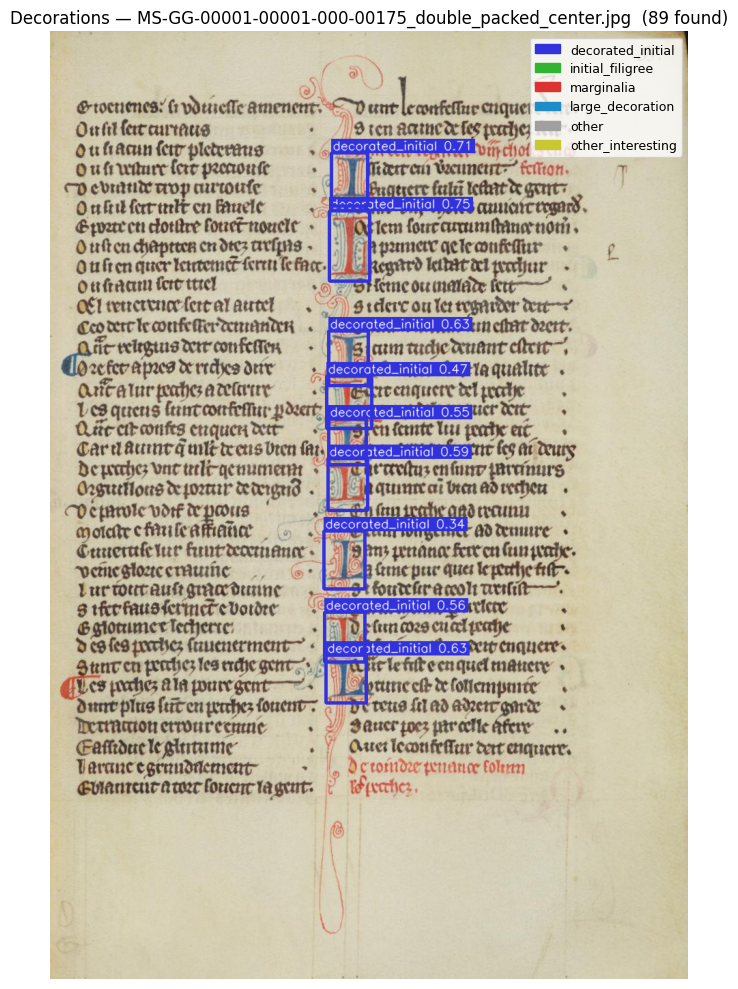

In [34]:
SAVE_ANNOTATED = False   # set False to skip saving

exclude_categories = {"other", "other_interesting"}

#viz = pre.bgr.copy()
viz = img_model_input.copy()

for d in detections_out:
    if d["category"] in exclude_categories:
        continue
    color = CATEGORY_COLORS.get(d["category"], CATEGORY_COLORS["other"])
    cv2.rectangle(viz, (d["x1"], d["y1"]), (d["x2"], d["y2"]), color, thickness=3)

    label_text = f"{d['category']} {d['confidence']:.2f}"
    (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
    # Background pill for readability
    cv2.rectangle(viz,
                  (d["x1"], d["y1"] - th - 6),
                  (d["x1"] + tw + 4, d["y1"]),
                  color, thickness=-1)
    cv2.putText(viz, label_text,
                (d["x1"] + 2, d["y1"] - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), thickness=1,
                lineType=cv2.LINE_AA)

# Legend
legend_patches = [
    mpatches.Patch(color=tuple(c / 255 for c in rgb[::-1]), label=cat)
    for cat, rgb in CATEGORY_COLORS.items()
]

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
ax.set_title(f"Decorations — {img_path.name}  ({len(detections_out)} found)")
ax.axis("off")
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.8)
plt.tight_layout()
plt.show()

if SAVE_ANNOTATED:
    out_dir = img_path.parent / "results"
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / (img_path.stem + "_decorations" + img_path.suffix)
    cv2.imwrite(str(out_path), viz)
    print(f"Saved: {out_path}")

## 10 — Count & Summarise by Category

In [ ]:
APPEND_TO_CSV = False  # set True to append a row to the pipeline results CSV

df = pd.DataFrame(detections_out)

if df.empty:
    print("No detections above threshold.")
else:
    summary = (
        df.groupby("category")
          .agg(count=("category", "size"),
               mean_conf=("confidence", "mean"),
               mean_area_px=("area_px", "mean"))
          .round(3)
          .sort_values("count", ascending=False)
    )
    print(summary.to_string())

    # Bar chart
    counts = df["category"].value_counts()
    colors_mpl = [
        tuple(c / 255 for c in CATEGORY_COLORS.get(cat, CATEGORY_COLORS["other"])[::-1])
        for cat in counts.index
    ]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(counts.index, counts.values, color=colors_mpl)
    ax.bar_label(bars)
    ax.set_title(f"Decoration counts — {img_path.name}")
    ax.set_ylabel("Count")
    ax.set_xlabel("Category")
    plt.tight_layout()
    plt.show()

if APPEND_TO_CSV and not df.empty:
    csv_path = img_path.parent / "results" / "results.csv"
    if not csv_path.is_file():
        print(f"CSV not found at {csv_path} — skipping append.")
    else:
        existing = pd.read_csv(csv_path)
        # Build one new column per category
        cat_counts = df["category"].value_counts().to_dict()
        row_idx = existing["filename"] == img_path.name
        if row_idx.any():
            for cat, cnt in cat_counts.items():
                col = f"deco_{cat}"
                if col not in existing.columns:
                    existing[col] = 0
                existing.loc[row_idx, col] = cnt
            existing.to_csv(csv_path, index=False)
            print(f"Updated {csv_path}")
        else:
            print(f"Filename {img_path.name!r} not found in CSV — skipping append.")